In [1]:
import numpy as np
from scipy.io import loadmat 
import json
import os 
import matplotlib.pyplot as plt
import polars as pl
print (os.getcwd())


# Stimulation patterns of 1 hour distributed across 32 channels (0-31 index)
with open("../single_electrode_exponential_interarrival_duration.json", "r") as f:
    stims = json.load(f)
    stims_df = pl.DataFrame(stims)

# Subtract the same 1000 ms init period that is subtracted from spike times (cell 2)
# so that stim and spike times share the same time base.
SIM_INIT_PERIOD_MS = 1000
stims_df = stims_df.with_columns(
    (pl.col("times_ms") - SIM_INIT_PERIOD_MS).alias("times_ms")
)

stims_df.head(10)
print (stims_df.shape)
print (stims_df.columns)

stims_df.head(10)

print (stims_df['times_ms'].describe())


/Users/shubhom/Documents/high_dimensional_stim_sim/data/electrical
(7353, 3)
['channels', 'times_ms', 'amplitudes_uA']
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 7353.0     │
│ null_count ┆ 0.0        │
│ mean       ┆ 1.7881e6   │
│ std        ┆ 1.0413e6   │
│ min        ┆ -996.0     │
│ 25%        ┆ 888225.0   │
│ 50%        ┆ 1.755895e6 │
│ 75%        ┆ 2.697954e6 │
│ max        ┆ 3.598924e6 │
└────────────┴────────────┘


In [2]:
# read spike_recorder # separator='\t' for tabs or '\s+' for any whitespace
lazy_dfs = []
for file in os.listdir():
    if file.startswith("spike_recorder") and file.endswith(".dat"):
        # Extract population name
        pop_name = file.replace("-", "_").split("_")[2]
        
        # scan_csv doesn't read the data yet, it just plans the operation
        lf = pl.scan_csv(
            file,
            has_header=False,
            separator="\t",
            new_columns=["sender", "time"],
            skip_rows=3
        ).drop_nulls().with_columns([pl.col("time").cast(pl.Float32) - pl.lit(SIM_INIT_PERIOD_MS).cast(pl.Float16),
                                    pl.lit(pop_name).alias("population").cast(pl.Int16),
                                    pl.col("sender").cast(pl.Int16)
                                    ])
        
        lazy_dfs.append(lf)    


all_activity_df = pl.concat(lazy_dfs).sort(["time", "population"]).collect()
print(all_activity_df.head(10))
print(all_activity_df.shape)

shape: (10, 3)
┌────────┬──────────┬────────────┐
│ sender ┆ time     ┆ population │
│ ---    ┆ ---      ┆ ---        │
│ i16    ┆ f32      ┆ i16        │
╞════════╪══════════╪════════════╡
│ 2746   ┆ 0.099976 ┆ 3863       │
│ 2968   ┆ 0.099976 ┆ 3864       │
│ 2003   ┆ 0.200012 ┆ 3861       │
│ 2790   ┆ 0.299988 ┆ 3863       │
│ 3564   ┆ 0.5      ┆ 3865       │
│ 3776   ┆ 0.5      ┆ 3866       │
│ 3820   ┆ 0.700012 ┆ 3866       │
│ 1590   ┆ 1.299988 ┆ 3861       │
│ 3809   ┆ 1.5      ┆ 3866       │
│ 979    ┆ 1.599976 ┆ 3859       │
└────────┴──────────┴────────────┘
(29224247, 3)


In [4]:
all_activity_df['time'].min(), all_activity_df['time'].max()

(0.0999755859375, 3601923.0)

In [5]:
stims_df['times_ms'].min(), stims_df['times_ms'].max()

(-996, 3598924)

In [7]:
import torch
import sys
import importlib
sys.path.insert(0, "../..")
import models
importlib.reload(models)
from models import NESTStimSpikeDataset

# --- Shared constants ---
BIN_MS = 5
N_STIM_CHANNELS = 32
N_OUTPUT_BINS = 50
N_INPUT_BINS = N_OUTPUT_BINS  # model processes full output window causally
HISTORY = 1  # >0 to prepend teacher-forced spike history as extra channels
KERNEL_SIZES = [3, 3]  # must match model conv kernel sizes

total_duration_ms = float(all_activity_df["time"].max())

# --- Build dataset (polars fast path) ---
dataset = NESTStimSpikeDataset(
    stim_df=stims_df,
    spike_df=all_activity_df,
    total_duration_ms=total_duration_ms,
    bin_size_ms=BIN_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    n_stim_channels=N_STIM_CHANNELS,
    presim_ms=0,
    history=HISTORY,
    kernel_sizes=KERNEL_SIZES,
    mode="stim_locked",
)

n_neurons = dataset.n_neurons
print(f"n_neurons: {n_neurons}")
print(f"n_total_bins: {dataset.n_total_bins}")
print(f"n_initial_state_bins (context for valid conv): {dataset.n_initial_state_bins}")
print(f"n_samples: {len(dataset)}")
print(f"stim_binned shape: {dataset.stim_binned.shape}")
print(f"spikes_binned shape: {dataset.spikes_binned.shape}")

x, y = dataset[0]
print(f"x shape: {x.shape}  (expected C x {dataset.n_initial_state_bins + N_INPUT_BINS})")
print(f"y shape: {y.shape}")

n_neurons: 3858
n_total_bins: 720384
n_initial_state_bins (context for valid conv): 4
n_samples: 7318
stim_binned shape: (32, 720384)
spikes_binned shape: (3858, 720384)
x shape: torch.Size([3890, 54])  (expected C x 54)
y shape: torch.Size([3858, 50])


In [8]:
# --- Find a sample whose window actually contains stimulation ---
SAMPLE_IDX = None
for idx in range(len(dataset)):
    t = dataset.sample_starts[idx]
    window = dataset.stim_binned[:, t:t + N_INPUT_BINS]
    if np.any(window != 0):
        SAMPLE_IDX = idx
        break

if SAMPLE_IDX is None:
    raise ValueError("No sample contains stimulation — check stim_binned alignment")

print(f"Using SAMPLE_IDX = {SAMPLE_IDX}")


Using SAMPLE_IDX = 0


Stim-centered windows : 2000
No-stim windows       : 2000
Rate vector dimension : 3858 neurons
  Stim-centered (70 ms, ±35 ms around event)  n=2000
    PC1–3 variance : [0.0081 0.0044 0.0039]  (cumul: 0.016)
    90% → PC1059,  95% → PC1311
  No-stim (70 ms, ≥70 ms clean buffer)  n=2000
    PC1–3 variance : [0.0052 0.0035 0.0033]  (cumul: 0.012)
    90% → PC1040,  95% → PC1287


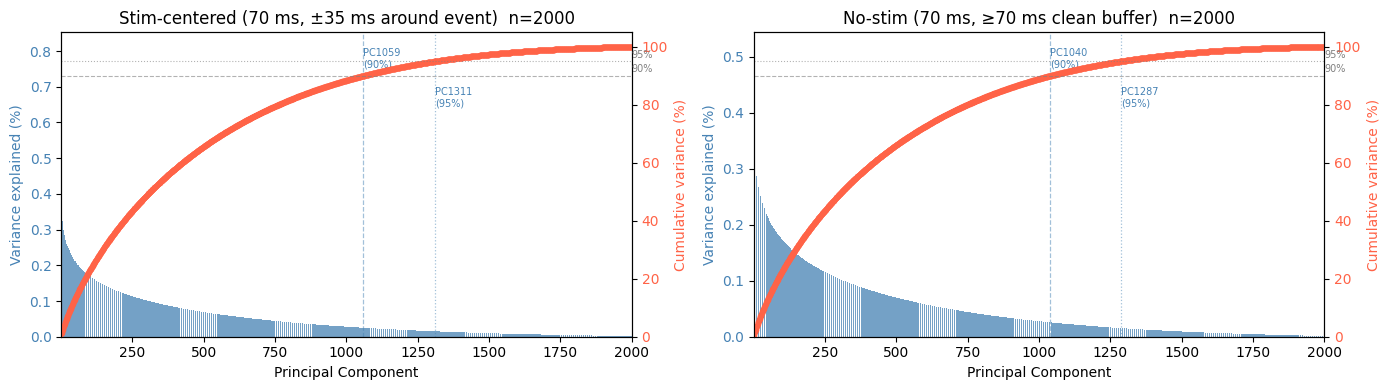

In [9]:
# ── Dimensionality analysis: stim-centered vs no-stim windows ────────────────
# WIN_MS = 70 ms → WIN_BINS = 14 bins @ 5 ms
# Stim windows  : 70 ms centered on each unique stim event (±35 ms)
# No-stim windows: 70 ms windows with zero stim AND ≥70 ms clean buffer on each side
from scipy.ndimage import binary_dilation
from sklearn.decomposition import PCA

WIN_MS      = 70
WIN_BINS    = WIN_MS // BIN_MS          # 14
HALF        = WIN_BINS // 2             # 7
BUFFER_BINS = WIN_BINS                  # 70 ms clean margin around no-stim windows
N_MAX       = 2000                      # cap per condition to keep PCA tractable
RNG_SEED    = 42
rng         = np.random.default_rng(RNG_SEED)

spikes  = dataset.spikes_binned   # (n_neurons, n_total_bins)
stim    = dataset.stim_binned     # (n_channels, n_total_bins)
n_neurons, n_total = spikes.shape
WIN_S   = WIN_MS / 1000.0

# ── 1. Stim-centered windows ──────────────────────────────────────────────────
stim_times_ms  = stims_df["times_ms"].to_numpy().astype(float)
stim_bins_raw  = np.sort((stim_times_ms / BIN_MS).astype(int))

# keep only events whose window fits inside the recording
in_bounds = (stim_bins_raw >= HALF) & (stim_bins_raw + HALF <= n_total)
stim_bins_raw = stim_bins_raw[in_bounds]

# deduplicate: skip events within WIN_BINS of the previous kept event
kept = [stim_bins_raw[0]]
for b in stim_bins_raw[1:]:
    if b - kept[-1] >= WIN_BINS:
        kept.append(b)
stim_events = np.array(kept)

if len(stim_events) > N_MAX:
    stim_events = np.sort(rng.choice(stim_events, N_MAX, replace=False))

stim_vecs = np.stack([
    spikes[:, b - HALF : b + HALF].sum(axis=1)
    for b in stim_events
]).astype(np.float32) / WIN_S

# ── 2. No-stim windows ────────────────────────────────────────────────────────
any_stim    = stim.any(axis=0)                                   # (n_total,) bool
# Mark any bin within BUFFER_BINS of a stim as contaminated
contaminated = binary_dilation(any_stim, iterations=BUFFER_BINS) # (n_total,) bool

# Cumsum trick: window [b, b+WIN_BINS) is clean iff sum(contaminated[b:b+WIN_BINS]) == 0
cs           = np.concatenate([[0], np.cumsum(contaminated.astype(np.int32))])
window_sums  = cs[WIN_BINS : n_total + 1] - cs[: n_total - WIN_BINS + 1]
clean_starts = np.where(window_sums == 0)[0]

if len(clean_starts) > N_MAX:
    clean_starts = np.sort(rng.choice(clean_starts, N_MAX, replace=False))

nostim_vecs = np.stack([
    spikes[:, b : b + WIN_BINS].sum(axis=1)
    for b in clean_starts
]).astype(np.float32) / WIN_S

print(f"Stim-centered windows : {len(stim_vecs)}")
print(f"No-stim windows       : {len(nostim_vecs)}")
print(f"Rate vector dimension : {stim_vecs.shape[1]} neurons")

# ── 3. PCA + scree plots ──────────────────────────────────────────────────────
def fit_scree(vecs):
    n = min(vecs.shape[0], vecs.shape[1])
    p = PCA(n_components=n).fit(vecs)
    evr  = p.explained_variance_ratio_
    return evr, np.cumsum(evr), n

def draw_scree(ax1, evr, cumr, n_comp, title):
    ax2 = ax1.twinx()
    ax1.bar(np.arange(1, n_comp + 1), evr * 100, color="steelblue", alpha=0.75)
    ax2.plot(np.arange(1, n_comp + 1), cumr * 100,
             color="tomato", marker="o", markersize=3, linewidth=1.5)
    for thresh, ls in [(90, "--"), (95, ":")]:
        ax2.axhline(thresh, color="gray", linestyle=ls, linewidth=0.8, alpha=0.6)
        ax2.text(n_comp + 0.3, thresh + 0.5, f"{thresh}%", color="gray", fontsize=7, va="bottom")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Variance explained (%)", color="steelblue")
    ax2.set_ylabel("Cumulative variance (%)", color="tomato")
    ax1.set_xlim(0.5, n_comp + 0.5)
    ax1.set_ylim(0)
    ax2.set_ylim(0, 105)
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax1.set_title(title)
    for thresh, ls in [(0.90, "--"), (0.95, ":")]:
        nx = int(np.searchsorted(cumr, thresh)) + 1
        ax1.axvline(nx, color="steelblue", linestyle=ls, linewidth=0.9, alpha=0.5)
        top = ax1.get_ylim()[1]
        ax1.text(nx + 0.2, top * (0.95 if thresh == 0.90 else 0.82),
                 f"PC{nx}\n({int(thresh*100)}%)", fontsize=7, color="steelblue", va="top")
    n90 = int(np.searchsorted(cumr, 0.90)) + 1
    n95 = int(np.searchsorted(cumr, 0.95)) + 1
    print(f"  {title}")
    print(f"    PC1–3 variance : {evr[:3].round(4)}  (cumul: {cumr[2]:.3f})")
    print(f"    90% → PC{n90},  95% → PC{n95}")

evr_s,  cumr_s,  n_s  = fit_scree(stim_vecs)
evr_ns, cumr_ns, n_ns = fit_scree(nostim_vecs)

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(14, 4))
draw_scree(axL, evr_s,  cumr_s,  n_s,
           f"Stim-centered (70 ms, ±35 ms around event)  n={len(stim_vecs)}")
draw_scree(axR, evr_ns, cumr_ns, n_ns,
           f"No-stim (70 ms, ≥70 ms clean buffer)  n={len(nostim_vecs)}")
plt.tight_layout()
plt.show()


Unique amplitudes (µA): [2. 3. 4. 5. 6.]
Computed STA for 160 (electrode, amplitude) combos


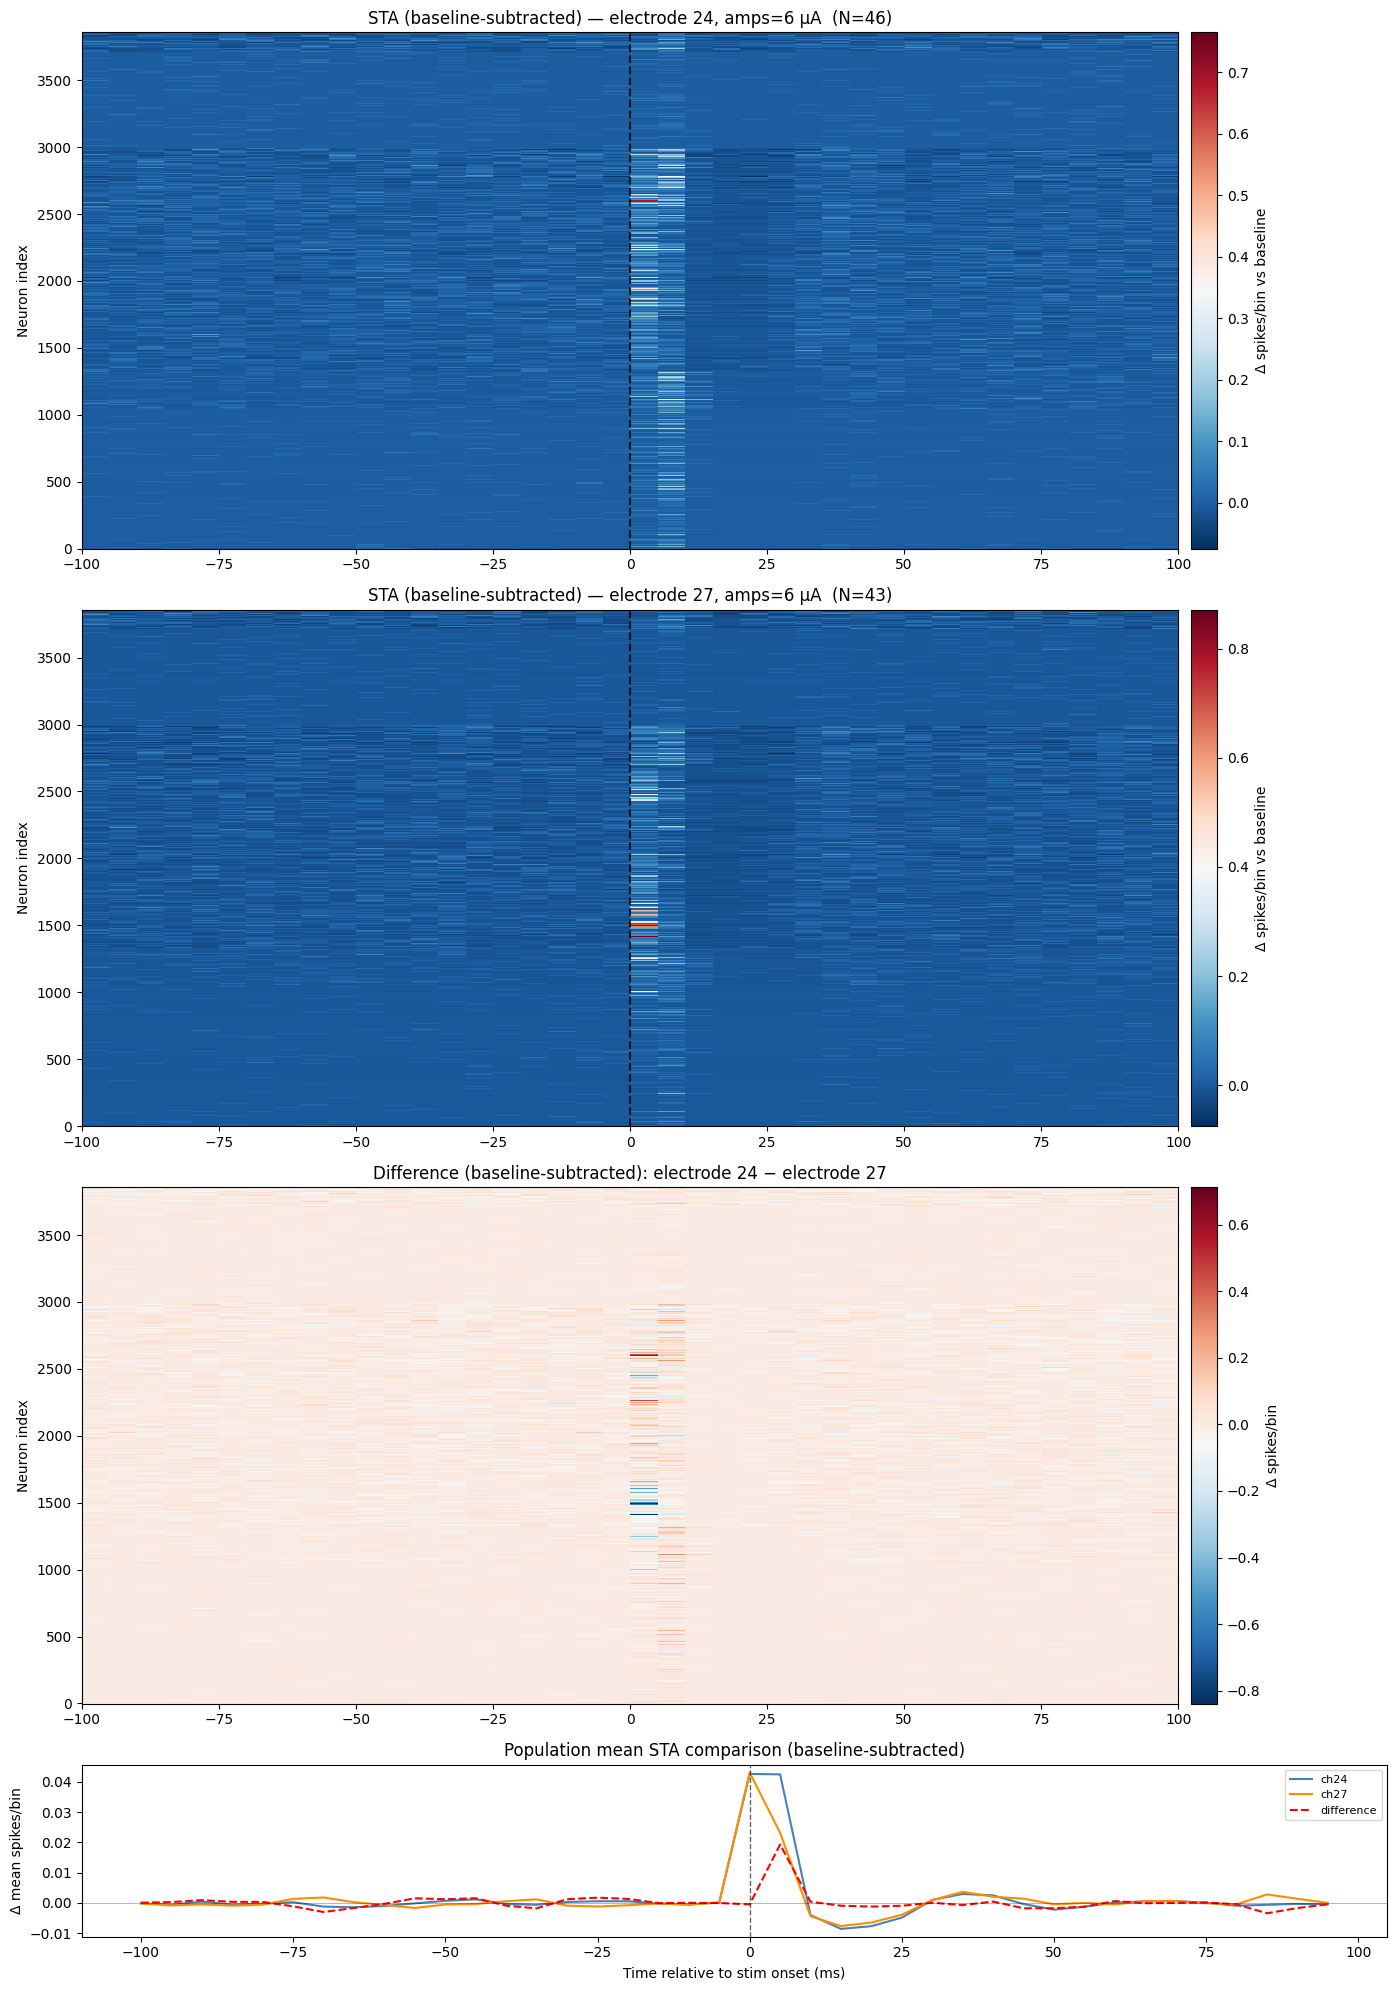

Saved comparison figure to ../../outputs/sta/sta_compare_ch24_vs_ch27_amps6.png


In [14]:

# =====================================================================
# Stimulation-triggered average (STA) — per neuron, per electrode, per current
# =====================================================================
BEFORE_MS = 100    # ms before stim onset
AFTER_MS  = 100   # ms after stim onset

before_bins = int(BEFORE_MS / BIN_MS)
after_bins  = int(AFTER_MS  / BIN_MS)
n_win_bins  = before_bins + after_bins
win_time    = np.arange(-before_bins, after_bins) * BIN_MS  # relative time axis (ms)

channels_arr = stims_df["channels"].to_numpy().astype(int)
times_arr    = stims_df["times_ms"].to_numpy().astype(float)
amps_arr     = stims_df["amplitudes_uA"].to_numpy().astype(float)

unique_amps = np.unique(amps_arr)
print(f"Unique amplitudes (µA): {unique_amps}")

# sta_by_key[(ch, amp)] -> (n_neurons, n_win_bins) mean STA
sta_by_key = {}
counts = {}

for amp in unique_amps:
    mask = (amps_arr == amp)
    ch_sub = channels_arr[mask]
    t_sub  = times_arr[mask]

    acc_sum   = np.zeros((N_STIM_CHANNELS, n_neurons, n_win_bins), dtype=np.float64)
    acc_count = np.zeros(N_STIM_CHANNELS, dtype=int)

    for ch_idx, t_ms in zip(ch_sub, t_sub):
        center = int(np.floor(t_ms / BIN_MS))
        lo, hi = center - before_bins, center + after_bins
        if lo < 0 or hi > dataset.n_total_bins:
            continue
        acc_sum[ch_idx]   += dataset.spikes_binned[:, lo:hi]
        acc_count[ch_idx] += 1

    for ch in range(N_STIM_CHANNELS):
        if acc_count[ch] > 0:
            sta_by_key[(ch, amp)] = acc_sum[ch] / acc_count[ch]  # (n_neurons, n_win_bins)
            counts[(ch, amp)] = int(acc_count[ch])

print(f"Computed STA for {len(sta_by_key)} (electrode, amplitude) combos")

# --- Save all results ---
sta_save_dir = os.path.join("..", "..", "outputs", "sta")
os.makedirs(sta_save_dir, exist_ok=True)

# --- Per-neuron baseline: mean spike rate across the full recording ---
# shape (n_neurons, 1) — used to mean-subtract in differential plots
neuron_baseline = dataset.spikes_binned.mean(axis=1, keepdims=True)  # (n_neurons, 1)

# =====================================================================
# Compare STA between two electrodes (or overall) across a set of amplitudes
# =====================================================================
TEST_CH  = [24, 27]
TEST_AMP = [6]

def weighted_avg_sta(ch, amp_list):
    """
    Count-weighted average STA.
    ch=None, amp_list=None -> average over ALL (channel, amplitude) combos.
    ch=int, amp_list=list  -> average over specified amplitudes for that channel.
    """
    if ch is None and amp_list is None:
        keys = list(sta_by_key.keys())
    elif amp_list is None:
        keys = [(ch, a) for a in unique_amps if (ch, a) in sta_by_key]
    else:
        keys = [(ch, a) for a in amp_list if (ch, a) in sta_by_key]

    total_sum   = np.zeros((n_neurons, n_win_bins), dtype=np.float64)
    total_count = 0
    for key in keys:
        n = counts[key]
        total_sum   += sta_by_key[key] * n
        total_count += n
    if total_count == 0:
        return None, 0
    return total_sum / total_count, total_count

sta_ch0,  n0  = weighted_avg_sta(TEST_CH[0], TEST_AMP)
sta_ch1,  n1  = weighted_avg_sta(TEST_CH[1], TEST_AMP)

if sta_ch0 is None or sta_ch1 is None:
    missing = TEST_CH[0] if sta_ch0 is None else TEST_CH[1]
    print(f"No matching events for electrode {missing} with amplitudes {TEST_AMP}")
    avail = sorted(set(amp for (ch, amp) in sta_by_key if ch == missing))
    print(f"  Available amplitudes: {avail}")
else:
    # Baseline-subtract each STA: remove per-neuron mean firing across all time
    sta_ch0_bs = sta_ch0  - neuron_baseline   # (n_neurons, n_win_bins)
    sta_ch1_bs = sta_ch1 - neuron_baseline
    sta_all = None
    sta_all_bs = sta_all - neuron_baseline if sta_all is not None else None

    # Difference between the two electrodes (baseline-subtracted)
    sta_diff = sta_ch0_bs - sta_ch1_bs       # (n_neurons, n_win_bins)

    amp_str  = ",".join(str(a) for a in TEST_AMP)
    bs_abs   = max(float(np.abs(sta_ch0_bs).max()), float(np.abs(sta_ch1_bs).max()), 1e-6)
    diff_abs = max(float(np.abs(sta_diff).max()), 1e-6)
    extent   = [win_time[0], win_time[-1] + BIN_MS, -0.5, n_neurons - 0.5]

    n_rows = 5 if sta_all_bs is not None else 4
    height_ratios = [3, 3, 3, 3, 1] if sta_all_bs is not None else [3, 3, 3, 1]
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 5 * n_rows),
                              gridspec_kw={"height_ratios": height_ratios})

    row = 0

    # --- Ch0 heatmap (baseline-subtracted) ---
    im0 = axes[row].imshow(sta_ch0_bs, aspect="auto", origin="lower", extent=extent,
                            cmap="RdBu_r",
                            interpolation="nearest")
    axes[row].axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.8)
    axes[row].set_ylabel("Neuron index")
    axes[row].set_title(f"STA (baseline-subtracted) — electrode {TEST_CH[0]}, amps={amp_str} µA  (N={n0})")
    fig.colorbar(im0, ax=axes[row], pad=0.01, label="Δ spikes/bin vs baseline")
    row += 1

    # --- Ch1 heatmap (baseline-subtracted) ---
    im1 = axes[row].imshow(sta_ch1_bs, aspect="auto", origin="lower", extent=extent,
                            cmap="RdBu_r", 
                            interpolation="nearest")
    axes[row].axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.8)
    axes[row].set_ylabel("Neuron index")
    axes[row].set_title(f"STA (baseline-subtracted) — electrode {TEST_CH[1]}, amps={amp_str} µA  (N={n1})")
    fig.colorbar(im1, ax=axes[row], pad=0.01, label="Δ spikes/bin vs baseline")
    row += 1

    # --- Global average STA (baseline-subtracted) ---
    if sta_all_bs is not None:
        all_abs = max(float(np.abs(sta_all_bs).max()), 1e-6)
        im_all = axes[row].imshow(sta_all_bs, aspect="auto", origin="lower", extent=extent,
                                   cmap="RdBu_r",
                                   interpolation="nearest")
        axes[row].axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.8)
        axes[row].set_ylabel("Neuron index")
        axes[row].set_title(f"STA (baseline-subtracted) — ALL electrodes & amplitudes  (N={n_all})")
        fig.colorbar(im_all, ax=axes[row], pad=0.01, label="Δ spikes/bin vs baseline")
        row += 1

    # --- Difference heatmap: ch0_bs − ch1_bs ---
    im_diff = axes[row].imshow(sta_diff, aspect="auto", origin="lower", extent=extent,
                                cmap="RdBu_r",
                                interpolation="nearest")
    # axes[row].axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.8)
    axes[row].set_ylabel("Neuron index")
    axes[row].set_title(f"Difference (baseline-subtracted): electrode {TEST_CH[0]} − electrode {TEST_CH[1]}")
    fig.colorbar(im_diff, ax=axes[row], pad=0.01, label="Δ spikes/bin")
    row += 1

    # --- Population mean traces ---
    pop0  = sta_ch0_bs.mean(axis=0)
    pop1  = sta_ch1_bs.mean(axis=0)
    pop_d = sta_diff.mean(axis=0)
    axes[row].plot(win_time, pop0, label=f"ch{TEST_CH[0]}", color="steelblue")
    axes[row].plot(win_time, pop1, label=f"ch{TEST_CH[1]}", color="darkorange")
    if sta_all_bs is not None:
        axes[row].plot(win_time, sta_all_bs.mean(axis=0), label="all", color="green", linestyle=":")
    axes[row].plot(win_time, pop_d, label="difference", color="red", linestyle="--")
    axes[row].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
    axes[row].axhline(0, color="black", linewidth=0.5, alpha=0.4)
    axes[row].set_xlabel("Time relative to stim onset (ms)")
    axes[row].set_ylabel("Δ mean spikes/bin")
    axes[row].set_title("Population mean STA comparison (baseline-subtracted)")
    axes[row].legend(fontsize=8)

    plt.tight_layout()
    fname = f"sta_compare_ch{TEST_CH[0]}_vs_ch{TEST_CH[1]}_amps{amp_str.replace(',','_')}.png"
    plt.savefig(os.path.join(sta_save_dir, fname), dpi=150)
    plt.show()
    print(f"Saved comparison figure to {sta_save_dir}/{fname}")


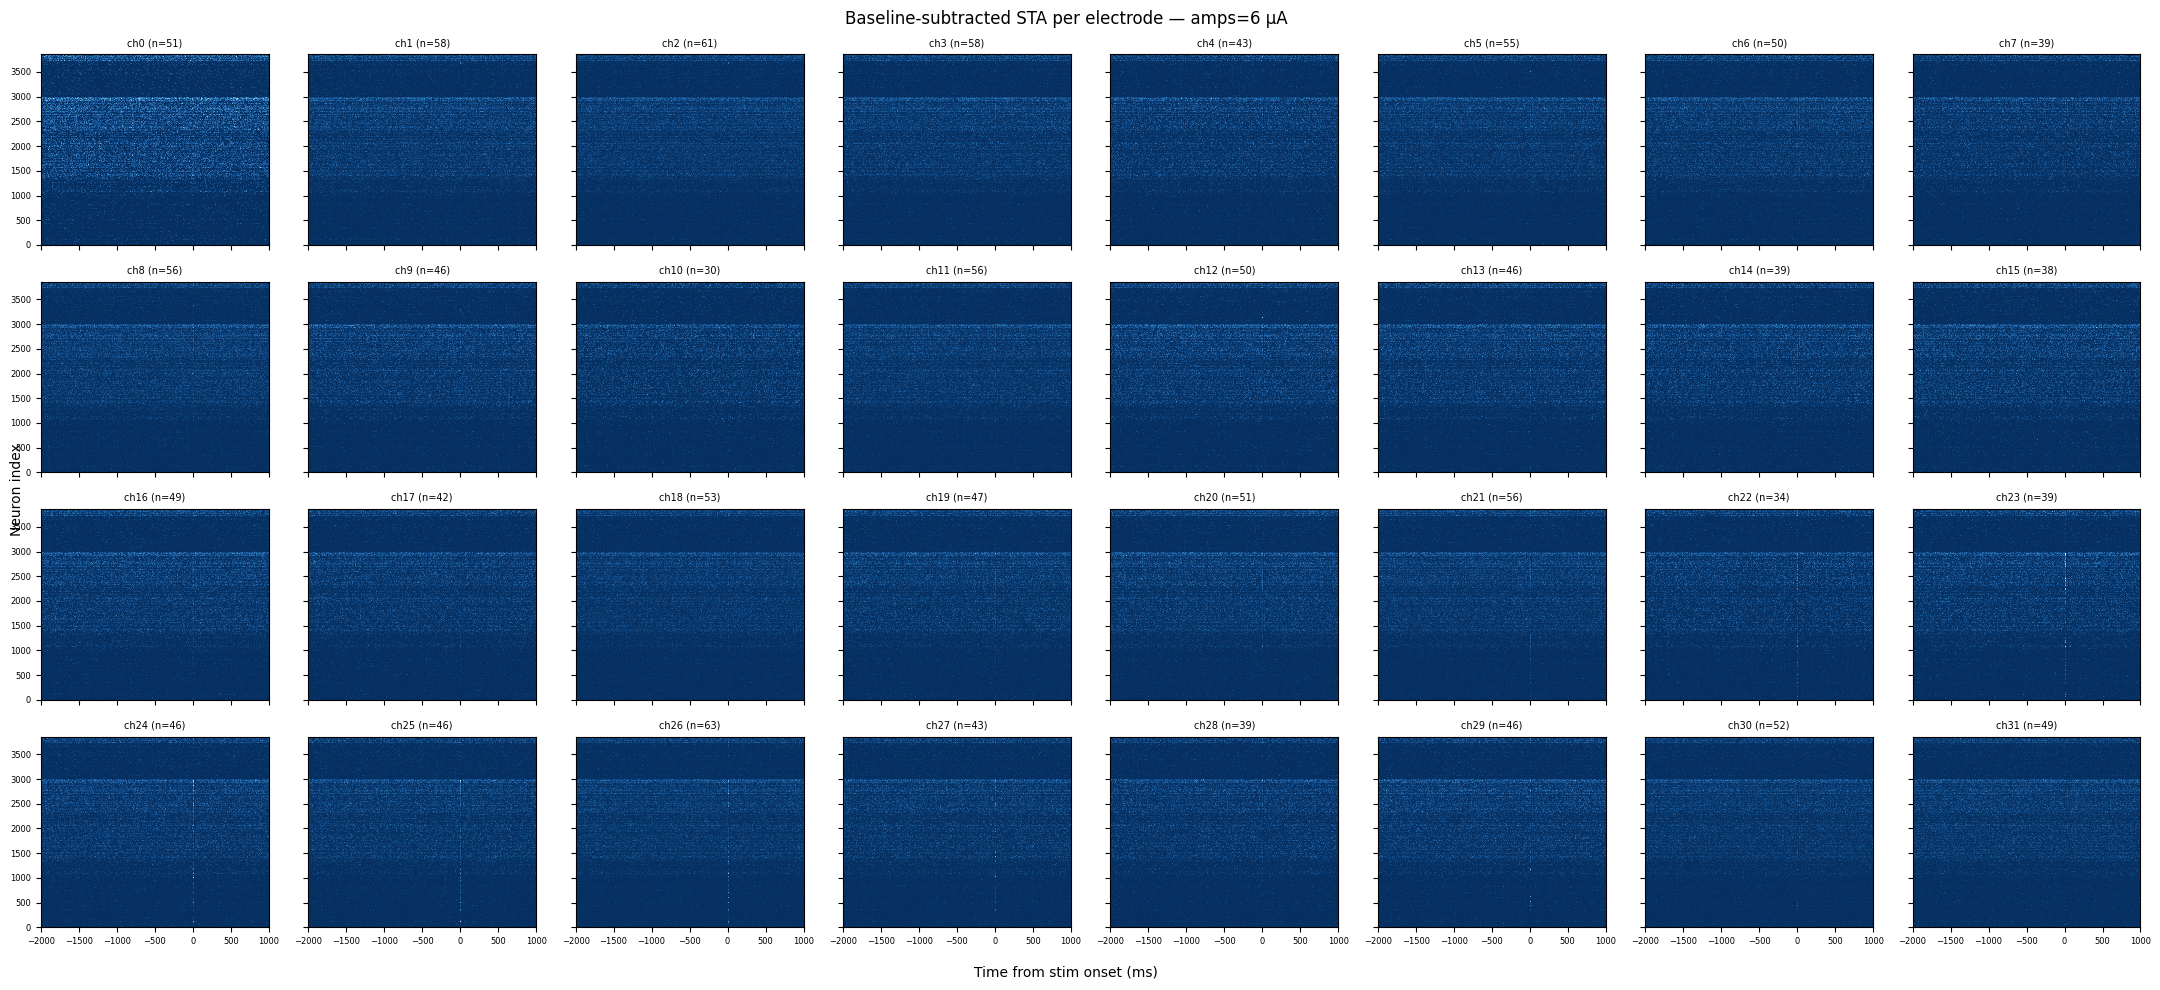

Saved all-electrode STA to ../../outputs/sta/sta_all_electrodes_amps6.png


In [11]:

# =====================================================================
# Population-mean baseline-subtracted STA for every electrode
# =====================================================================
amp_str = ",".join(str(a) for a in TEST_AMP)

fig2, axes2 = plt.subplots(4, 8, figsize=(22, 10), sharex=True, sharey=True)
axes2 = axes2.flatten()

for ch in range(N_STIM_CHANNELS):
    ax = axes2[ch]
    sta_ch, n_ch = weighted_avg_sta(ch, TEST_AMP)
    if sta_ch is None or n_ch == 0:
        ax.set_title(f"ch{ch}\n(no events)", fontsize=7)
        continue
    ax.imshow(sta_ch, aspect="auto", origin="lower",
               extent=extent, cmap="RdBu_r",
               interpolation="nearest")

    # ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.8)
    ax.set_title(f"ch{ch} (n={n_ch})", fontsize=7)

for ax in axes2:
    ax.tick_params(labelsize=6)

fig2.supxlabel("Time from stim onset (ms)", fontsize=10)
fig2.supylabel("Neuron index", fontsize=10)
fig2.suptitle(f"Baseline-subtracted STA per electrode — amps={amp_str} µA", fontsize=12)
plt.tight_layout()

fname2 = f"sta_all_electrodes_amps{amp_str.replace(',','_')}.png"
plt.savefig(os.path.join(sta_save_dir, fname2), dpi=150)
plt.show()
print(f"Saved all-electrode STA to {sta_save_dir}/{fname2}")


In [12]:
# =====================================================================
# Define trials from stim events, split train / val / test
# =====================================================================

n_bins_total = int(np.floor(total_duration_ms / BIN_MS))

# Build trial list (only stim events whose window fits in the recording)
channels_arr = stims_df["channels"].to_numpy().astype(int)
times_arr = stims_df["times_ms"].to_numpy().astype(float)
amps_arr = stims_df["amplitudes_uA"].to_numpy().astype(float)

trials_all = []
for i in range(len(channels_arr)):
    start_bin = int(np.floor(float(times_arr[i]) / BIN_MS))
    end_bin = start_bin + N_OUTPUT_BINS
    if start_bin >= 0 and end_bin <= n_bins_total:
        trials_all.append({
            "trial_id": len(trials_all),
            "channel": int(channels_arr[i]),
            "amplitude_uA": float(amps_arr[i]),
            "time_ms": float(times_arr[i]),
            "start_bin": start_bin,
            "end_bin": end_bin,
        })

print(f"Valid trials: {len(trials_all)} / {len(channels_arr)} stim events")

# --- Assign splits per (channel, amplitude) combo ---
# Sorted by time within each group: last → test, 2nd-to-last → val, rest → train
trials_pl = pl.DataFrame(trials_all).sort("time_ms")
combo_groups = trials_pl.group_by(["channel", "amplitude_uA"]).agg(
    pl.col("trial_id").sort_by("time_ms")
)

split_map = {}
combo_rows = []

for row in combo_groups.iter_rows():
    ch, amp, trial_ids = row
    ids = list(trial_ids)
    n = len(ids)
    n_test = 1 if n >= 2 else 0
    n_val  = 1 if n >= 3 else 0
    n_train = n - n_test - n_val

    if n >= 3:
        split_map[ids[-1]] = "test"
        split_map[ids[-2]] = "val"
        for tid in ids[:-2]:
            split_map[tid] = "train"
    elif n == 2:
        split_map[ids[-1]] = "test"
        split_map[ids[0]] = "train"
    else:
        split_map[ids[0]] = "train"

    combo_rows.append({
        "channel": ch, "amplitude_uA": amp,
        "count": n, "train": n_train, "val": n_val, "test": n_test,
    })

combo_df = pl.DataFrame(combo_rows).sort(["channel", "amplitude_uA"])
print("\n--- Trial splits per (electrode, current) combo ---")
print(combo_df)

# Annotate each trial with its split
for t in trials_all:
    t["split"] = split_map[t["trial_id"]]

# --- Remove overlapping trials (prefer test > val > train) ---
trials_sorted = sorted(trials_all, key=lambda x: x["start_bin"])
priority = {"test": 2, "val": 1, "train": 0}
kept = []
discarded = []

for t in trials_sorted:
    drop_current = False
    # If current overlaps the last kept trial, resolve by priority
    while kept and kept[-1]["end_bin"] > t["start_bin"]:
        if priority[t["split"]] > priority[kept[-1]["split"]]:
            d = kept.pop()
            discarded.append({**d, "reason": f"overlaps {t['split']} trial {t['trial_id']}"})
        else:
            discarded.append({**t, "reason": f"overlaps {kept[-1]['split']} trial {kept[-1]['trial_id']}"})
            drop_current = True
            break
    if not drop_current:
        kept.append(t)

train_trials = [t for t in kept if t["split"] == "train"]
val_trials   = [t for t in kept if t["split"] == "val"]
test_trials  = [t for t in kept if t["split"] == "test"]

print(f"\n--- After removing overlaps ---")
print(f"Train: {len(train_trials)}  Val: {len(val_trials)}  Test: {len(test_trials)}  Discarded: {len(discarded)}")
if discarded:
    print(pl.DataFrame([
        {k: d[k] for k in ["trial_id", "channel", "amplitude_uA", "split", "reason"]}
        for d in discarded
    ]))

Valid trials: 7352 / 7353 stim events

--- Trial splits per (electrode, current) combo ---
shape: (160, 6)
┌─────────┬──────────────┬───────┬───────┬─────┬──────┐
│ channel ┆ amplitude_uA ┆ count ┆ train ┆ val ┆ test │
│ ---     ┆ ---          ┆ ---   ┆ ---   ┆ --- ┆ ---  │
│ i64     ┆ f64          ┆ i64   ┆ i64   ┆ i64 ┆ i64  │
╞═════════╪══════════════╪═══════╪═══════╪═════╪══════╡
│ 0       ┆ 2.0          ┆ 34    ┆ 32    ┆ 1   ┆ 1    │
│ 0       ┆ 3.0          ┆ 38    ┆ 36    ┆ 1   ┆ 1    │
│ 0       ┆ 4.0          ┆ 40    ┆ 38    ┆ 1   ┆ 1    │
│ 0       ┆ 5.0          ┆ 55    ┆ 53    ┆ 1   ┆ 1    │
│ 0       ┆ 6.0          ┆ 51    ┆ 49    ┆ 1   ┆ 1    │
│ …       ┆ …            ┆ …     ┆ …     ┆ …   ┆ …    │
│ 31      ┆ 2.0          ┆ 46    ┆ 44    ┆ 1   ┆ 1    │
│ 31      ┆ 3.0          ┆ 45    ┆ 43    ┆ 1   ┆ 1    │
│ 31      ┆ 4.0          ┆ 52    ┆ 50    ┆ 1   ┆ 1    │
│ 31      ┆ 5.0          ┆ 44    ┆ 42    ┆ 1   ┆ 1    │
│ 31      ┆ 6.0          ┆ 49    ┆ 47    ┆ 1   ┆ 1   

In [13]:
# =====================================================================
# Create trial-based DataLoaders from shared binned arrays
# =====================================================================
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_ds = dataset.with_trials(train_trials)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_ds = dataset.with_trials(val_trials) if val_trials else None
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE) if val_ds else None

test_ds = dataset.with_trials(test_trials) if test_trials else None
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE) if test_ds else None

print(f"Train: {len(train_ds)} trials ({len(train_loader)} batches)")
if val_ds:  print(f"Val:   {len(val_ds)} trials ({len(val_loader)} batches)")
if test_ds: print(f"Test:  {len(test_ds)} trials ({len(test_loader)} batches)")

x0, y0 = train_ds[0]
print(f"\nSample shapes — x: {x0.shape}  y: {y0.shape}")

Train: 4637 trials (73 batches)
Val:   117 trials (2 batches)
Test:  132 trials (3 batches)

Sample shapes — x: torch.Size([3890, 54])  y: torch.Size([3858, 50])


In [ ]:
# =====================================================================
# Train StimEncodingCNN with Poisson NLL loss
# =====================================================================
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
from tqdm.auto import tqdm
importlib.reload(models)
from models import StimEncodingCNN

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

CONV_CHANNELS = [512, 256]
FC_DIMS = [512]

model = StimEncodingCNN(
    n_stim_channels=N_STIM_CHANNELS,
    n_neurons=n_neurons,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    conv_channels=CONV_CHANNELS,
    kernel_sizes=KERNEL_SIZES,
    fc_dims=FC_DIMS,
    history=HISTORY,
    use_init_state=True,
).to(device)

print(f"Model total_conv_reduction: {model.total_conv_reduction}")
print(f"Dataset n_initial_state_bins: {dataset.n_initial_state_bins}")
assert model.total_conv_reduction == dataset.n_initial_state_bins, \
    "Model conv reduction must match dataset context bins!"

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)
loss_fn = nn.PoissonNLLLoss(log_input=True)

N_EPOCHS = 50
EARLY_STOP_PATIENCE = 8
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

epoch_bar = tqdm(range(N_EPOCHS), desc="Training")
for epoch in epoch_bar:
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1} train", leave=False):
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

    v = float("nan")
    if val_loader:
        model.eval()
        vr = 0.0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1} val", leave=False):
                x, y = x.to(device), y.to(device)
                vr += loss_fn(model(x), y).item()
        v = vr / len(val_loader)
        scheduler.step(v)

        if v < best_val_loss:
            best_val_loss = v
            best_state = {k: p.clone() for k, p in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
    val_losses.append(v)

    lr_now = optimizer.param_groups[0]["lr"]
    epoch_bar.set_postfix(train=f"{train_losses[-1]:.4f}", val=f"{v:.4f}", lr=f"{lr_now:.1e}")

    if val_loader and epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best model (val loss = {best_val_loss:.4f})")

# --- Test evaluation ---
if test_loader:
    model.eval()
    tr = 0.0
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Test eval"):
            x, y = x.to(device), y.to(device)
            tr += loss_fn(model(x), y).item()
    print(f"\nTest loss: {tr / len(test_loader):.4f}")

# --- Save model artifacts ---
run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join("..", "..", "outputs", "models", run_stamp)
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_dir, "model.pt"))

meta = {
    "epoch": len(train_losses),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
    "n_neurons": n_neurons,
    "n_stim_channels": N_STIM_CHANNELS,
    "n_input_bins": N_INPUT_BINS,
    "n_output_bins": N_OUTPUT_BINS,
    "bin_ms": BIN_MS,
    "conv_channels": CONV_CHANNELS,
    "kernel_sizes": KERNEL_SIZES,
    "fc_dims": FC_DIMS,
    "history": HISTORY,
    "use_init_state": True,
    "train_trials": train_trials,
    "val_trials": val_trials,
    "test_trials": test_trials,
}
with open(os.path.join(save_dir, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved to {save_dir}")


In [ ]:
# =====================================================================
# Load a saved model (set LOAD_DIR to skip training or compare runs)
# =====================================================================
# Point to an existing run, or leave as save_dir to use the model just trained.
# To load a previous run, set e.g.:  LOAD_DIR = "../../outputs/models/20260311_122035"
LOAD_DIR = "../../outputs/models/20260312_012405"

meta_json = os.path.join(LOAD_DIR, "meta.json")
meta_pt   = os.path.join(LOAD_DIR, "meta.pt")
if os.path.isfile(meta_json):
    with open(meta_json) as f:
        meta = json.load(f)
else:
    meta = torch.load(meta_pt, weights_only=False)

print(f"Loading model from: {LOAD_DIR}")
print(f"  epochs trained : {meta['epoch']}")
print(f"  best val loss  : {meta['best_val_loss']:.4f}")


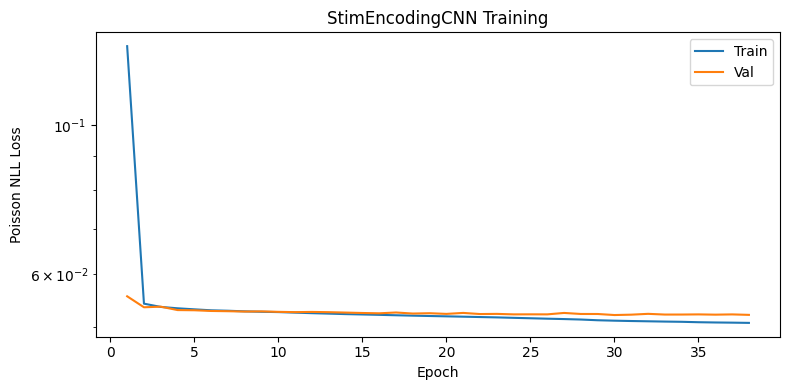

In [ ]:
n_ep = len(train_losses)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_ep + 1), train_losses, label="Train")
if val_losses and not all(v != v for v in val_losses):  # has non-NaN val losses
    ax.plot(range(1, n_ep + 1), val_losses, label="Val")
ax.set_yscale('log')
ax.set_xlabel("Epoch")
ax.set_ylabel("Poisson NLL Loss")
ax.legend()
ax.set_title("StimEncodingCNN Training")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "learning_curves.png"))
plt.show()

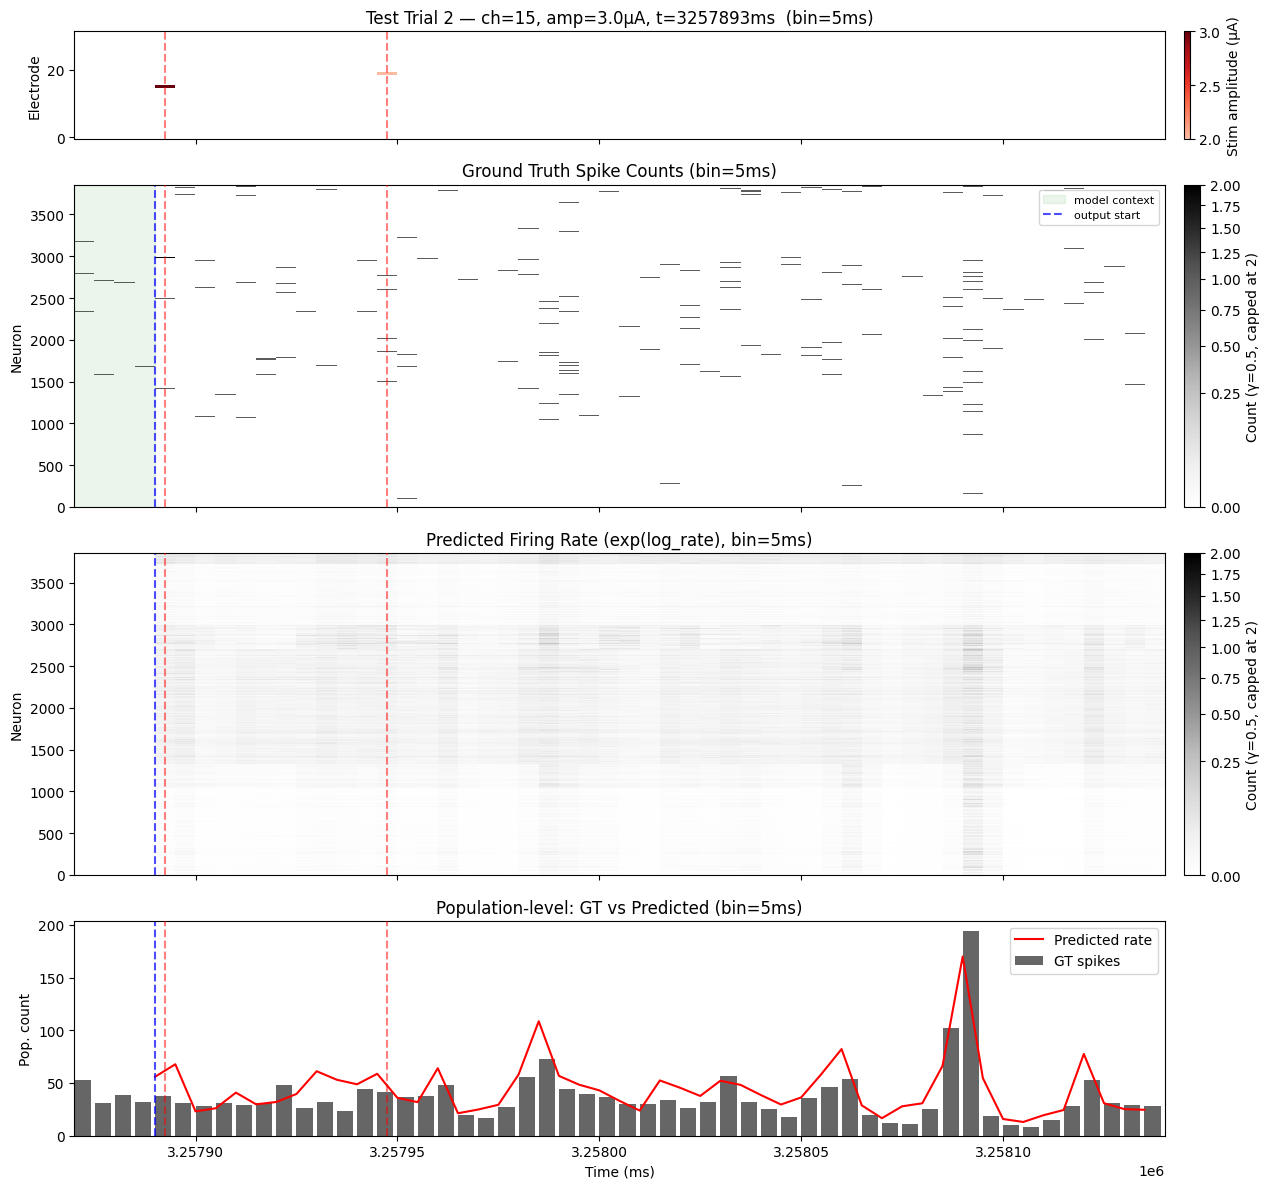

In [ ]:

# =====================================================================
# Visualize a sample test trial: input stim, neural activity, pred vs GT
# =====================================================================
from matplotlib.colors import PowerNorm, LinearSegmentedColormap

sample_idx = 2

if test_ds and len(test_ds) > 0:
    x_sample, y_sample = test_ds[sample_idx]
    trial_info = test_trials[sample_idx]
    t0 = trial_info["start_bin"]  # trial start bin (output begins here)

    model.eval()
    with torch.no_grad():
        pred_sample = model(x_sample.unsqueeze(0).to(device))
        pred_rates = torch.exp(pred_sample).squeeze(0).cpu().numpy()  # (n_neurons, N_OUTPUT_BINS)
    y_np = y_sample.numpy()   # (n_neurons, N_OUTPUT_BINS)
    x_np = x_sample.numpy()   # (C, x_width)

    # --- Visualization window: context (n_initial_state_bins) | output ---
    # viz_start matches the first bin the model sees as context input
    ctx = dataset.n_initial_state_bins  # = sum(k-1 for k in kernel_sizes), e.g. 4
    viz_start = max(0, t0 - ctx)
    viz_end   = t0 + N_OUTPUT_BINS
    n_viz_bins = viz_end - viz_start

    time_axis = np.arange(viz_start, viz_end) * BIN_MS
    trial_ms  = t0 * BIN_MS
    out_offset = t0 - viz_start  # index where output starts in viz array

    # --- Raw data for viz window ---
    gt_full   = dataset.spikes_binned[:, viz_start:viz_end].astype(float)
    stim_full = dataset.stim_binned[:, viz_start:viz_end].astype(float)

    # Place model output into the output region only
    pred_full = np.zeros((n_neurons, n_viz_bins), dtype=np.float32)
    pred_full[:, out_offset:out_offset + N_OUTPUT_BINS] = pred_rates

    # --- Stim event times (for dashed red lines across all panels) ---
    stim_event_bins = np.where(np.any(stim_full != 0, axis=0))[0]
    stim_times_ms = [time_axis[sb] + BIN_MS / 2 for sb in stim_event_bins]

    # --- Shared colour scale ---
    gamma = 0.5
    spike_vmax = max(1.0, float(gt_full.max()))
    spike_norm = PowerNorm(gamma=gamma, vmin=0, vmax=spike_vmax)
    ext      = [time_axis[0], time_axis[-1] + BIN_MS, -0.5, n_neurons - 0.5]
    stim_ext = [time_axis[0], time_axis[-1] + BIN_MS, -0.5, N_STIM_CHANNELS - 0.5]

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                              gridspec_kw={"height_ratios": [1, 3, 3, 2]})

    # (1) Stimulation — truncated Reds colormap so lightest value is never white
    stim_masked = np.ma.masked_where(stim_full == 0, stim_full)
    base_reds = plt.cm.Reds(np.linspace(0.25, 1.0, 256))
    stim_cmap = LinearSegmentedColormap.from_list("TruncReds", base_reds)
    stim_cmap.set_bad(color="white", alpha=0.0)
    stim_im = axes[0].imshow(stim_masked, aspect="auto", origin="lower", extent=stim_ext,
                              cmap=stim_cmap, interpolation="nearest")
    axes[0].set_ylabel("Electrode")
    axes[0].set_ylim(-0.5, N_STIM_CHANNELS - 0.5)
    axes[0].set_title(f"Test Trial {sample_idx} \u2014 ch={trial_info['channel']}, "
                      f"amp={trial_info['amplitude_uA']}\u00b5A, t={trial_info['time_ms']:.0f}ms  "
                      f"(bin={BIN_MS}ms)")
    stim_cbar = fig.colorbar(stim_im, ax=axes[0], pad=0.015)
    stim_cbar.set_label("Stim amplitude (\u00b5A)")

    # (2) Ground truth — full viz window
    im_gt = axes[1].imshow(gt_full, aspect="auto", origin="lower", extent=ext,
                           cmap="Greys", norm=spike_norm, interpolation="nearest")
    ctx_start_ms = viz_start * BIN_MS
    axes[1].axvspan(ctx_start_ms, trial_ms, color="green", alpha=0.08, label="model context")
    axes[1].axvline(trial_ms, color="blue", linewidth=1.5, linestyle="--", alpha=0.7, label="output start")
    axes[1].set_ylabel("Neuron")
    axes[1].set_title(f"Ground Truth Spike Counts (bin={BIN_MS}ms)")
    axes[1].legend(loc="upper right", fontsize=8)
    fig.colorbar(im_gt, ax=axes[1], pad=0.015,
                 label=f"Count (\u03b3={gamma}, capped at {spike_vmax:.0f})")

    # (3) Predicted — output region only
    im_pred = axes[2].imshow(pred_full, aspect="auto", origin="lower", extent=ext,
                             cmap="Greys", norm=spike_norm, interpolation="nearest")
    axes[2].axvline(trial_ms, color="blue", linewidth=1.5, linestyle="--", alpha=0.7)
    axes[2].set_ylabel("Neuron")
    axes[2].set_title(f"Predicted Firing Rate (exp(log_rate), bin={BIN_MS}ms)")
    fig.colorbar(im_pred, ax=axes[2], pad=0.015,
                 label=f"Count (\u03b3={gamma}, capped at {spike_vmax:.0f})")

    # (4) Population-level comparison
    gt_pop   = gt_full.sum(axis=0)
    pred_pop = pred_full[:, out_offset:].sum(axis=0)
    pred_time = time_axis[out_offset:]
    axes[3].bar(time_axis, gt_pop, width=BIN_MS * 0.8, alpha=0.6,
                label="GT spikes", color="black", align="edge")
    axes[3].plot(pred_time, pred_pop, color="red", linewidth=1.5, label="Predicted rate")
    axes[3].axvline(trial_ms, color="blue", linewidth=1.5, linestyle="--", alpha=0.7)
    axes[3].set_ylabel("Pop. count")
    axes[3].set_xlabel("Time (ms)")
    axes[3].legend(loc="upper right")
    axes[3].set_title(f"Population-level: GT vs Predicted (bin={BIN_MS}ms)")
    # Invisible colorbar to match width of panels above
    dummy_cbar = fig.colorbar(im_pred, ax=axes[3], pad=0.015)
    dummy_cbar.ax.set_visible(False)

    # Dashed red vertical lines at stim times across ALL panels
    for stim_t in stim_times_ms:
        for ax in axes:
            ax.axvline(stim_t, color="red", linewidth=1.5, linestyle="--", alpha=0.5, zorder=5)

    plt.tight_layout()
    viz_dir = os.path.join(save_dir, "trial_viz")
    os.makedirs(viz_dir, exist_ok=True)
    plt.savefig(os.path.join(viz_dir, f"test_trial_{sample_idx}_visualization.png"), dpi=150)
    plt.show()
else:
    print("No test trials available for visualization.")


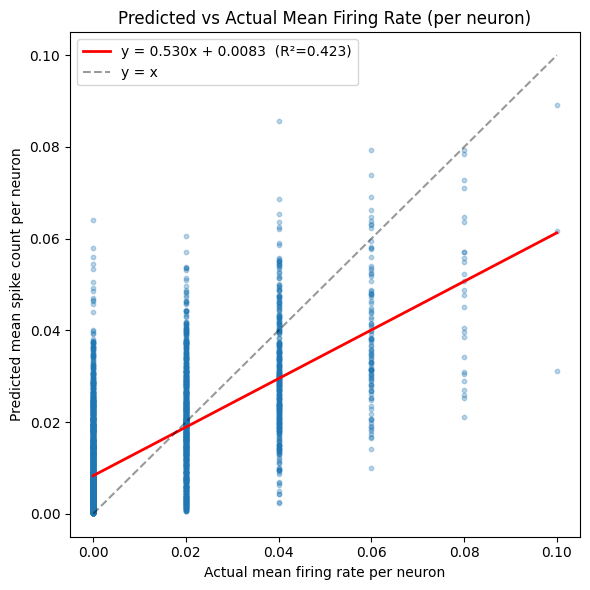

In [ ]:

actual = y_np.mean(axis=1).flatten()
predicted = pred_rates.mean(axis=1).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(actual, predicted, alpha=0.3, s=10)

# Line of best fit
m, b = np.polyfit(actual, predicted, 1)
x_fit = np.linspace(actual.min(), actual.max(), 100)
plt.plot(x_fit, m * x_fit + b, color="red", linewidth=2,
         label=f"y = {m:.3f}x + {b:.4f}  (R²={np.corrcoef(actual, predicted)[0,1]**2:.3f})")

plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()],
         'k--', alpha=0.4, label="y = x")
plt.xlabel("Actual mean firing rate per neuron")
plt.ylabel("Predicted mean spike count per neuron")
plt.title("Predicted vs Actual Mean Firing Rate (per neuron)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "predicted_vs_actual.png"))
plt.show()


Test set: 132 trials  |  pred (132, 3858, 50)  true (132, 3858, 50)
Train-average lookup: 160 unique (electrode, amplitude) combos
Test trials with a matching train average: 132 / 132

Model   —  median r: 0.073  |  mean FVE: 0.007
Ceiling —  median r: 0.006  |  mean FVE: -0.033


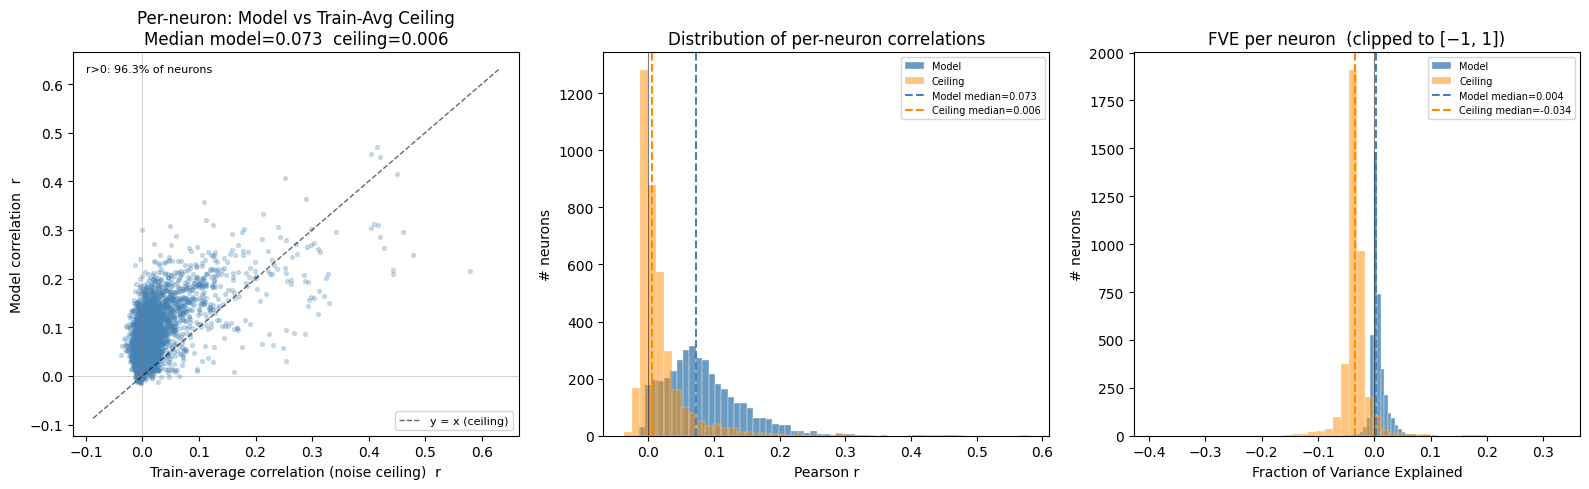

Saved to ../../outputs/models/20260312_012405/per_neuron_corr_fve.png


In [ ]:

# =====================================================================
# Per-neuron correlation and FVE vs train-average noise ceiling
# =====================================================================
# Noise ceiling for each test trial: average ground-truth spike response
# across all training trials that share the same (electrode, amplitude).
# This measures the ceiling set by the stimulus-driven response mean.
# =====================================================================
from scipy.stats import pearsonr
from collections import defaultdict

# --- 1. Collect all test predictions and targets ---------------------
model.eval()
all_pred_list, all_true_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred_log = model(xb.to(device))
        all_pred_list.append(torch.exp(pred_log).cpu().numpy())
        all_true_list.append(yb.numpy())

all_pred = np.concatenate(all_pred_list, axis=0)  # (N_test, n_neurons, n_bins)
all_true = np.concatenate(all_true_list, axis=0)  # (N_test, n_neurons, n_bins)
N_test = all_true.shape[0]
print(f"Test set: {N_test} trials  |  pred {all_pred.shape}  true {all_true.shape}")

# --- 2. Build train-average lookup: (ch, amp) -> mean spike response -
# Group train trials by (channel, amplitude_uA), average their binned spikes
train_avg_by_key = {}   # (ch, amp) -> (n_neurons, n_output_bins) mean
train_count_by_key = {}

key_to_train_bins = defaultdict(list)
for tr in train_trials:
    key = (tr["channel"], tr["amplitude_uA"])
    key_to_train_bins[key].append(tr["start_bin"])

for key, starts in key_to_train_bins.items():
    acc = np.zeros((n_neurons, N_OUTPUT_BINS), dtype=np.float64)
    for sb in starts:
        acc += dataset.spikes_binned[:, sb : sb + N_OUTPUT_BINS]
    train_avg_by_key[key] = (acc / len(starts)).astype(np.float32)
    train_count_by_key[key] = len(starts)

print(f"Train-average lookup: {len(train_avg_by_key)} unique (electrode, amplitude) combos")

# --- 3. Build ceiling predictions for each test trial ----------------
ceil_pred = np.zeros_like(all_true)  # (N_test, n_neurons, n_bins)
n_matched = 0
for i, tr in enumerate(test_trials):
    key = (tr["channel"], tr["amplitude_uA"])
    if key in train_avg_by_key:
        ceil_pred[i] = train_avg_by_key[key]
        n_matched += 1
    # else: leave as zeros (no training data for this combo)

print(f"Test trials with a matching train average: {n_matched} / {N_test}")

# --- 4. Per-neuron correlation helper --------------------------------
def per_neuron_corr(pred, true):
    """Pearson r per neuron; pred/true shape (N, n_neurons, T)."""
    n = pred.shape[1]
    rs = np.zeros(n)
    for i in range(n):
        p = pred[:, i, :].ravel()
        t = true[:, i, :].ravel()
        if p.std() > 1e-8 and t.std() > 1e-8:
            rs[i] = pearsonr(p, t)[0]
    return rs

r_model = per_neuron_corr(all_pred, all_true)
r_ceil  = per_neuron_corr(ceil_pred, all_true)

# --- 5. FVE per neuron -----------------------------------------------
def per_neuron_fve(pred, true):
    n = pred.shape[1]
    fve = np.zeros(n)
    for i in range(n):
        p = pred[:, i, :].ravel()
        t = true[:, i, :].ravel()
        ss_res = np.sum((p - t) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        fve[i] = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    return fve

fve_model = per_neuron_fve(all_pred, all_true)
fve_ceil  = per_neuron_fve(ceil_pred, all_true)

print(f"\nModel   —  median r: {np.nanmedian(r_model):.3f}  |  mean FVE: {np.nanmean(fve_model):.3f}")
print(f"Ceiling —  median r: {np.nanmedian(r_ceil):.3f}  |  mean FVE: {np.nanmean(fve_ceil):.3f}")

# --- 6. Plots --------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Scatter: model r vs ceiling r per neuron
ax = axes[0]
all_r = np.concatenate([r_model, r_ceil])
lim = max(abs(np.nanmin(all_r)) - 0.05, np.nanmax(all_r) + 0.05)
lim_lo, lim_hi = np.nanmin(all_r) - 0.05, np.nanmax(all_r) + 0.05
ax.scatter(r_ceil, r_model, alpha=0.25, s=8, c="steelblue", rasterized=True)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1, alpha=0.6, label="y = x (ceiling)")
ax.axhline(0, color="gray", lw=0.5, alpha=0.5)
ax.axvline(0, color="gray", lw=0.5, alpha=0.5)
ax.set_xlabel("Train-average correlation (noise ceiling)  r")
ax.set_ylabel("Model correlation  r")
ax.set_title(
    f"Per-neuron: Model vs Train-Avg Ceiling\n"
    f"Median model={np.nanmedian(r_model):.3f}  ceiling={np.nanmedian(r_ceil):.3f}"
)
ax.legend(fontsize=8)
frac_pos = (r_model > 0).mean()
ax.text(0.03, 0.97, f"r>0: {frac_pos:.1%} of neurons",
        transform=ax.transAxes, va="top", fontsize=8)

# (b) Histogram of per-neuron model correlations
ax = axes[1]
ax.hist(r_model, bins=50, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.8, label="Model")
ax.hist(r_ceil,  bins=50, color="darkorange", edgecolor="white", linewidth=0.3, alpha=0.5, label="Ceiling")
ax.axvline(np.nanmedian(r_model), color="steelblue", lw=1.5, linestyle="--",
           label=f"Model median={np.nanmedian(r_model):.3f}")
ax.axvline(np.nanmedian(r_ceil),  color="darkorange", lw=1.5, linestyle="--",
           label=f"Ceiling median={np.nanmedian(r_ceil):.3f}")
ax.axvline(0, color="black", lw=0.8, alpha=0.5)
ax.set_xlabel("Pearson r")
ax.set_ylabel("# neurons")
ax.set_title("Distribution of per-neuron correlations")
ax.legend(fontsize=7)

# (c) Histogram of FVE
ax = axes[2]
ax.hist(np.clip(fve_model, -1, 1), bins=50, color="steelblue", edgecolor="white",
        linewidth=0.3, alpha=0.8, label="Model")
ax.hist(np.clip(fve_ceil,  -1, 1), bins=50, color="darkorange", edgecolor="white",
        linewidth=0.3, alpha=0.5, label="Ceiling")
ax.axvline(np.nanmedian(fve_model), color="steelblue", lw=1.5, linestyle="--",
           label=f"Model median={np.nanmedian(fve_model):.3f}")
ax.axvline(np.nanmedian(fve_ceil),  color="darkorange", lw=1.5, linestyle="--",
           label=f"Ceiling median={np.nanmedian(fve_ceil):.3f}")
ax.axvline(0, color="black", lw=0.8, alpha=0.5)
ax.set_xlabel("Fraction of Variance Explained")
ax.set_ylabel("# neurons")
ax.set_title("FVE per neuron  (clipped to [−1, 1])")
ax.legend(fontsize=7)

plt.tight_layout()
corr_path = os.path.join(save_dir, "per_neuron_corr_fve.png")
plt.savefig(corr_path, dpi=150)
plt.show()
print(f"Saved to {corr_path}")


In [ ]:
# =====================================================================
# Save per-(electrode, current) STA comparison figures: actual / model / diff
# =====================================================================
from collections import defaultdict
from matplotlib.colors import TwoSlopeNorm
from torch.utils.data import DataLoader
from pathlib import Path
from models import StimEncodingCNN

# Fall back to the latest saved run if save_dir/model are not already in memory.
if "save_dir" not in globals() or save_dir is None:
    model_root = Path("../../outputs/models")
    save_dir = str(sorted([p for p in model_root.iterdir() if p.is_dir()])[-1])
    print(f"Using latest model directory: {save_dir}")

local_device = globals().get("device", torch.device("mps" if torch.backends.mps.is_available() else "cpu"))

if "model" not in globals() or model is None:
    _meta_json = os.path.join(save_dir, "meta.json")
    _meta_pt   = os.path.join(save_dir, "meta.pt")
    if os.path.isfile(_meta_json):
        with open(_meta_json) as _f:
            meta = json.load(_f)
    else:
        meta = torch.load(_meta_pt, weights_only=False)
    model = StimEncodingCNN(
        n_stim_channels=meta["n_stim_channels"],
        n_neurons=meta["n_neurons"],
        n_input_bins=meta["n_input_bins"],
        n_output_bins=meta["n_output_bins"],
        conv_channels=meta.get("conv_channels", [256, 256]),
        kernel_sizes=meta.get("kernel_sizes", [3, 3]),
        fc_dims=meta.get("fc_dims", [256]),
        history=meta.get("history", HISTORY),
        use_init_state=meta.get("use_init_state", False),
    ).to(local_device)
    model.load_state_dict(torch.load(os.path.join(save_dir, "model.pt"), weights_only=True, map_location=local_device))
    model.eval()
    print(f"Loaded model from {save_dir}")

if "neuron_baseline" not in globals() or neuron_baseline is None:
    neuron_baseline = dataset.spikes_binned.mean(axis=1, keepdims=True)

sta_model_dir = os.path.join(save_dir, "sta")
os.makedirs(sta_model_dir, exist_ok=True)

analysis_trials = train_trials + val_trials + test_trials
analysis_ds = dataset.with_trials(analysis_trials)
analysis_loader = DataLoader(analysis_ds, batch_size=32, shuffle=False)

sum_true_by_key = {}
sum_pred_by_key = {}
count_by_key = defaultdict(int)
trial_ptr = 0

model.eval()
with torch.no_grad():
    for xb, yb in analysis_loader:
        pred = torch.exp(model(xb.to(local_device))).cpu().numpy()
        true = yb.numpy()
        batch_n = true.shape[0]

        for j in range(batch_n):
            tr = analysis_trials[trial_ptr + j]
            key = (tr["channel"], tr["amplitude_uA"])
            if key not in sum_true_by_key:
                sum_true_by_key[key] = np.zeros_like(true[j], dtype=np.float32)
                sum_pred_by_key[key] = np.zeros_like(pred[j], dtype=np.float32)
            sum_true_by_key[key] += true[j]
            sum_pred_by_key[key] += pred[j]
            count_by_key[key] += 1

        trial_ptr += batch_n

extent_sta = [0, N_OUTPUT_BINS * BIN_MS, -0.5, n_neurons - 0.5]
saved_paths = []

for (ch, amp) in sorted(count_by_key.keys()):
    n = count_by_key[(ch, amp)]
    sta_true = sum_true_by_key[(ch, amp)] / n - neuron_baseline
    sta_pred = sum_pred_by_key[(ch, amp)] / n - neuron_baseline
    sta_diff = sta_true - sta_pred

    shared_abs = max(float(np.abs(sta_true).max()), float(np.abs(sta_pred).max()), 1e-6)
    diff_abs = max(float(np.abs(sta_diff).max()), 1e-6)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

    im0 = axes[0].imshow(
        sta_true,
        aspect="auto", origin="lower",
        extent=extent_sta, cmap="RdBu_r",
        interpolation="nearest",
    )
    axes[0].axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.9)
    axes[0].set_ylabel("Neuron index")
    axes[0].set_title(f"Original STA (baseline-subtracted) — ch={ch}, amp={amp} uA, n={n}")
    fig.colorbar(im0, ax=axes[0], pad=0.015, label="Delta spikes/bin vs baseline")

    im1 = axes[1].imshow(
        sta_pred,
        aspect="auto", origin="lower",
        extent=extent_sta, cmap="RdBu_r",
        interpolation="nearest",
    )
    axes[1].axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.9)
    axes[1].set_ylabel("Neuron index")
    axes[1].set_title("Model-predicted STA (baseline-subtracted)")
    fig.colorbar(im1, ax=axes[1], pad=0.015, label="Delta spikes/bin vs baseline")

    im2 = axes[2].imshow(
        sta_diff,
        aspect="auto", origin="lower",
        extent=extent_sta, cmap="RdBu_r",
        interpolation="nearest",
    )
    axes[2].axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.9)
    axes[2].set_ylabel("Neuron index")
    axes[2].set_xlabel(f"Time from stim onset (ms, bin={BIN_MS} ms)")
    axes[2].set_title("Original minus model")
    fig.colorbar(im2, ax=axes[2], pad=0.015, label="Delta spikes/bin")

    plt.tight_layout()
    amp_str = f"{amp:g}".replace(".", "p")
    out_path = os.path.join(sta_model_dir, f"sta_compare_ch{ch:02d}_amp{amp_str}uA.png")
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    saved_paths.append(out_path)

print(f"Saved {len(saved_paths)} STA comparison figures to {sta_model_dir}")
print("First few files:")
for path in saved_paths[:5]:
    print(path)


In [ ]:
# ── Dimensionality analysis: stim-centered vs no-stim windows ────────────────
# WIN_MS = 70 ms → WIN_BINS = 14 bins @ 5 ms
# Stim windows  : 70 ms centered on each unique stim event (±35 ms)
# No-stim windows: 70 ms windows with zero stim AND ≥70 ms clean buffer on each side
from scipy.ndimage import binary_dilation
from sklearn.decomposition import PCA

WIN_MS      = 70
WIN_BINS    = WIN_MS // BIN_MS          # 14
HALF        = WIN_BINS // 2             # 7
BUFFER_BINS = WIN_BINS                  # 70 ms clean margin around no-stim windows
N_MAX       = 2000                      # cap per condition to keep PCA tractable
RNG_SEED    = 42
rng         = np.random.default_rng(RNG_SEED)

spikes  = dataset.spikes_binned   # (n_neurons, n_total_bins)
stim    = dataset.stim_binned     # (n_channels, n_total_bins)
n_neurons, n_total = spikes.shape
WIN_S   = WIN_MS / 1000.0

# ── 1. Stim-centered windows ──────────────────────────────────────────────────
stim_times_ms  = stims_df["times_ms"].to_numpy().astype(float)
stim_bins_raw  = np.sort((stim_times_ms / BIN_MS).astype(int))

# keep only events whose window fits inside the recording
in_bounds = (stim_bins_raw >= HALF) & (stim_bins_raw + HALF <= n_total)
stim_bins_raw = stim_bins_raw[in_bounds]

# deduplicate: skip events within WIN_BINS of the previous kept event
kept = [stim_bins_raw[0]]
for b in stim_bins_raw[1:]:
    if b - kept[-1] >= WIN_BINS:
        kept.append(b)
stim_events = np.array(kept)

if len(stim_events) > N_MAX:
    stim_events = np.sort(rng.choice(stim_events, N_MAX, replace=False))

stim_vecs = np.stack([
    spikes[:, b - HALF : b + HALF].sum(axis=1)
    for b in stim_events
]).astype(np.float32) / WIN_S

# ── 2. No-stim windows ────────────────────────────────────────────────────────
any_stim    = stim.any(axis=0)                                   # (n_total,) bool
# Mark any bin within BUFFER_BINS of a stim as contaminated
contaminated = binary_dilation(any_stim, iterations=BUFFER_BINS) # (n_total,) bool

# Cumsum trick: window [b, b+WIN_BINS) is clean iff sum(contaminated[b:b+WIN_BINS]) == 0
cs           = np.concatenate([[0], np.cumsum(contaminated.astype(np.int32))])
window_sums  = cs[WIN_BINS : n_total + 1] - cs[: n_total - WIN_BINS + 1]
clean_starts = np.where(window_sums == 0)[0]

if len(clean_starts) > N_MAX:
    clean_starts = np.sort(rng.choice(clean_starts, N_MAX, replace=False))

nostim_vecs = np.stack([
    spikes[:, b : b + WIN_BINS].sum(axis=1)
    for b in clean_starts
]).astype(np.float32) / WIN_S

print(f"Stim-centered windows : {len(stim_vecs)}")
print(f"No-stim windows       : {len(nostim_vecs)}")
print(f"Rate vector dimension : {stim_vecs.shape[1]} neurons")

# ── 3. PCA + scree plots ──────────────────────────────────────────────────────
def fit_scree(vecs, n_max=50):
    n = min(n_max, vecs.shape[0], vecs.shape[1])
    p = PCA(n_components=n).fit(vecs)
    evr  = p.explained_variance_ratio_
    return evr, np.cumsum(evr), n

def draw_scree(ax1, evr, cumr, n_comp, title):
    ax2 = ax1.twinx()
    ax1.bar(np.arange(1, n_comp + 1), evr * 100, color="steelblue", alpha=0.75)
    ax2.plot(np.arange(1, n_comp + 1), cumr * 100,
             color="tomato", marker="o", markersize=3, linewidth=1.5)
    for thresh, ls in [(90, "--"), (95, ":")]:
        ax2.axhline(thresh, color="gray", linestyle=ls, linewidth=0.8, alpha=0.6)
        ax2.text(n_comp + 0.3, thresh + 0.5, f"{thresh}%", color="gray", fontsize=7, va="bottom")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Variance explained (%)", color="steelblue")
    ax2.set_ylabel("Cumulative variance (%)", color="tomato")
    ax1.set_xlim(0.5, n_comp + 0.5)
    ax1.set_ylim(0)
    ax2.set_ylim(0, 105)
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax1.set_title(title)
    for thresh, ls in [(0.90, "--"), (0.95, ":")]:
        nx = int(np.searchsorted(cumr, thresh)) + 1
        ax1.axvline(nx, color="steelblue", linestyle=ls, linewidth=0.9, alpha=0.5)
        top = ax1.get_ylim()[1]
        ax1.text(nx + 0.2, top * (0.95 if thresh == 0.90 else 0.82),
                 f"PC{nx}\n({int(thresh*100)}%)", fontsize=7, color="steelblue", va="top")
    n90 = int(np.searchsorted(cumr, 0.90)) + 1
    n95 = int(np.searchsorted(cumr, 0.95)) + 1
    print(f"  {title}")
    print(f"    PC1–3 variance : {evr[:3].round(4)}  (cumul: {cumr[2]:.3f})")
    print(f"    90% → PC{n90},  95% → PC{n95}")

evr_s,  cumr_s,  n_s  = fit_scree(stim_vecs)
evr_ns, cumr_ns, n_ns = fit_scree(nostim_vecs)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4))
draw_scree(axL, evr_s,  cumr_s,  n_s,
           f"Stim-centered (70 ms, ±35 ms around event)  n={len(stim_vecs)}")
draw_scree(axR, evr_ns, cumr_ns, n_ns,
           f"No-stim (70 ms, ≥70 ms clean buffer)  n={len(nostim_vecs)}")
plt.tight_layout()
plt.show()
